In [3]:
import pandas as pd 
import numpy as np

from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler

from keras.models import Sequential
from keras.layers import Dense
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

file_path = 'Cafe_2022_for_ANN.csv'

df = pd.read_csv(file_path)

df.set_index('ts', inplace=True)

display(df)

,dh,dn,db,rh,wb,kW,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6,National_holiday,db_12h,wb_12h,db_24h,wb_24h
ts,,,,,,,,,,,,,,,,,,
2022-01-02 00:00:00+00:00,-0.774991,-0.250116,21.118430,27.490167,14.626107,20.1,0,0,0,0,0,0,1,0,11.10500,9.761608,12.478700,11.864235
2022-01-02 00:15:00+00:00,-0.801696,-0.275942,21.668930,27.600708,15.066867,22.8,0,0,0,0,0,0,1,0,11.89481,10.376387,11.849750,11.224006
2022-01-02 00:30:00+00:00,-0.828401,-0.301768,22.219430,27.711250,15.507627,21.1,0,0,0,0,0,0,1,0,12.68462,10.991166,11.220800,10.583776
2022-01-02 00:45:00+00:00,-0.855105,-0.327594,22.769930,27.821792,15.948387,21.5,0,0,0,0,0,0,1,0,13.47443,11.605945,10.591850,9.943547
2022-01-02 01:00:00+00:00,-0.881810,-0.353420,23.320430,27.932333,16.389147,21.1,0,0,0,0,0,0,1,0,14.26424,12.220724,9.962900,9.303317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-31 22:00:00+00:00,-1.048328,-0.017964,36.372530,64.097666,31.676850,18.0,0,0,0,0,0,1,0,0,48.86678,38.300113,33.761540,27.702305
2022-12-31 22:15:00+00:00,-1.041229,0.004448,36.120537,64.480791,31.514095,18.1,0,0,0,0,0,1,0,0,49.84586,38.854436,33.925528,27.745095
2022-12-31 22:30:00+00:00,-1.034130,0.026860,35.868545,64.863916,31.351340,19.3,0,0,0,0,0,1,0,0,50.82494,39.408760,34.089515,27.787885


In [4]:
X = df.drop('kW', axis = 1)
y = df.kW

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

# Split data into training and temporary data (80% training, 20% temporary)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# Split temporary data into testing and validation sets (50% testing, 50% validation)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


#Standardize features by removing the mean and scaling to unit variance
scaler=StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 128)               2304      
                                                                 
 dense_6 (Dense)             (None, 128)               16512     
                                                                 
 dense_7 (Dense)             (None, 128)               16512     
                                                                 
 dense_8 (Dense)             (None, 128)               16512     
                                                                 
 dense_9 (Dense)             (None, 1)                 129       
                                                                 
Total params: 51969 (203.00 KB)
Trainable params: 51969 (203.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/500


87

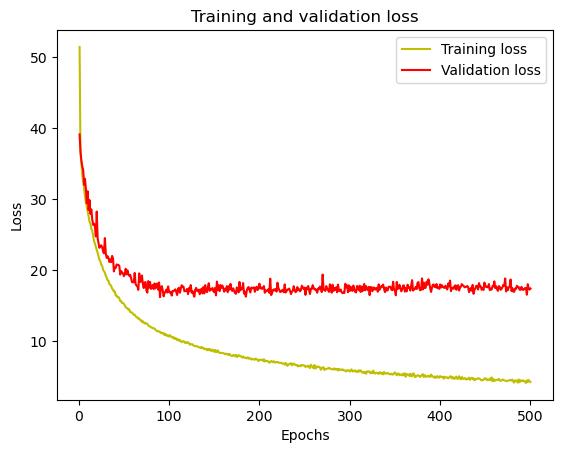

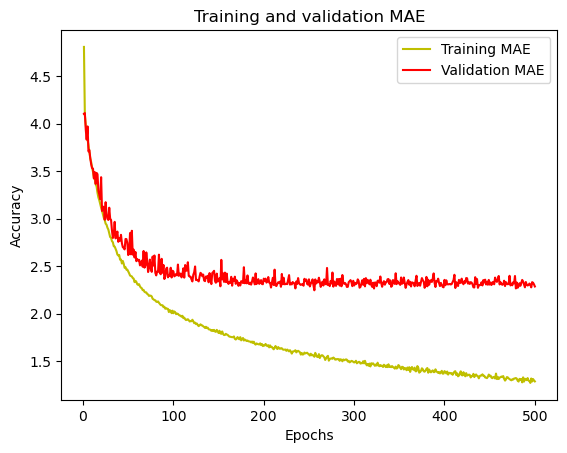

110/110 [==============================] - 0s 2ms/step
Training R^2: 0.9578436301265727
Validation R^2: 0.7925396611347917


In [8]:
epoch_values = 500

# define the model
# Experiment with deeper and wider networks

# Sequential constructor automatically/implicitly creates an input layer when the first layer is added to the model. Its shape is determined by the "input_dim" parameter of the first layer
model = Sequential()

# Dense layers (all connected) are added to the neural network with the specified neuron amount
# 128 neurons in the 1st hidden layer 
model.add(Dense(128, input_dim=17, activation='relu'))

# 64 neurons in the 2nd hidden layer
model.add(Dense(128, activation='tanh'))

# 64 neurons in the 2nd hidden layer
model.add(Dense(128, activation='relu'))

    # 64 neurons in the 2nd hidden layer
model.add(Dense(128, activation='relu'))

# Output layer, linear activation function does nothing except adding the results of previous neurons together
model.add(Dense(1, activation='linear'))

model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
model.summary()

history = model.fit(X_train_scaled, y_train, validation_data=[X_val_scaled, y_val] , epochs = epoch_values)
#validation_data=[X_test, y_test]

#plot the training and validation accuracy and loss at each epoch
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


acc = history.history['mae']
val_acc = history.history['val_mae']
plt.plot(epochs, acc, 'y', label='Training MAE')
plt.plot(epochs, val_acc, 'r', label='Validation MAE')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


# 1. Obtain predictions for both training and testing sets
train_predictions = model.predict(X_train_scaled)
val_predictions = model.predict(X_val_scaled)

# 2. Calculate R^2 scores
train_r2 = r2_score(y_train, train_predictions)
val_r2 = r2_score(y_val, val_predictions)

print("Training R^2:", train_r2)
print("Validation R^2:", val_r2)

Took 26 min and 27 seconds to train the model

In [9]:
# Save the model
model.save('ANN_2022_Model.keras')

In [6]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.models import load_model

model = load_model('ANN_2022_Model.keras')

test_predictions = model.predict(X_test_scaled)

test_r2 = r2_score(y_test, test_predictions)

testMaeScore = mean_absolute_error(y_test, test_predictions)
print("MAE of the test set:", testMaeScore)

testMseScore = (mean_squared_error(y_test, test_predictions))
print("MSE of the test set:", testMseScore)

print("Test R^2:", test_r2)



110/110 [==============================] - 1s 2ms/step
MAE of the test set: 2.238943904315756
MSE of the test set: 15.467101242470319
Test R^2: 0.8101549585786579


In [11]:
X_whole_dataset_scaled = scaler.transform(X)

y_whole_dataset_pred = model.predict(X_whole_dataset_scaled)

display(y)
display(y_whole_dataset_pred)

1092/1092 [==============================] - 2s 2ms/step


ts
2022-01-02 00:00:00+00:00    20.1
2022-01-02 00:15:00+00:00    22.8
2022-01-02 00:30:00+00:00    21.1
2022-01-02 00:45:00+00:00    21.5
2022-01-02 01:00:00+00:00    21.1
                             ... 
2022-12-31 22:00:00+00:00    18.0
2022-12-31 22:15:00+00:00    18.1
2022-12-31 22:30:00+00:00    19.3
2022-12-31 22:45:00+00:00    16.9
2022-12-31 23:00:00+00:00    19.3
Name: kW, Length: 34941, dtype: float64

array([[22.089756],
       [22.274216],
       [21.91767 ],
       ...,
       [19.292084],
       [19.39562 ],
       [19.865246]], dtype=float32)

In [12]:
whole_dataset_r2 = r2_score(y, y_whole_dataset_pred)

print("Whole Dataset R^2:", whole_dataset_r2)

Whole Dataset R^2: 0.9265444918026121


In [13]:
real_pred_combined = y.copy()

display(real_pred_combined)

real_pred_combined = pd.DataFrame(real_pred_combined)

display(real_pred_combined)

ts
2022-01-02 00:00:00+00:00    20.1
2022-01-02 00:15:00+00:00    22.8
2022-01-02 00:30:00+00:00    21.1
2022-01-02 00:45:00+00:00    21.5
2022-01-02 01:00:00+00:00    21.1
                             ... 
2022-12-31 22:00:00+00:00    18.0
2022-12-31 22:15:00+00:00    18.1
2022-12-31 22:30:00+00:00    19.3
2022-12-31 22:45:00+00:00    16.9
2022-12-31 23:00:00+00:00    19.3
Name: kW, Length: 34941, dtype: float64

,kW
ts,
2022-01-02 00:00:00+00:00,20.1
2022-01-02 00:15:00+00:00,22.8
2022-01-02 00:30:00+00:00,21.1
2022-01-02 00:45:00+00:00,21.5
2022-01-02 01:00:00+00:00,21.1
...,...
2022-12-31 22:00:00+00:00,18.0
2022-12-31 22:15:00+00:00,18.1
2022-12-31 22:30:00+00:00,19.3


In [14]:
real_pred_combined.rename(columns={'kW' : 'Real kW'}, inplace=True)
real_pred_combined['Predicted kW'] = y_whole_dataset_pred

display(real_pred_combined)

,Real kW,Predicted kW
ts,,
2022-01-02 00:00:00+00:00,20.1,22.089756
2022-01-02 00:15:00+00:00,22.8,22.274216
2022-01-02 00:30:00+00:00,21.1,21.917669
2022-01-02 00:45:00+00:00,21.5,21.581829
2022-01-02 01:00:00+00:00,21.1,21.577829
...,...,...
2022-12-31 22:00:00+00:00,18.0,17.900400
2022-12-31 22:15:00+00:00,18.1,18.456127
2022-12-31 22:30:00+00:00,19.3,19.292084


In [15]:
real_pred_combined.to_csv('ANN_2022_predictions.csv', index=True)